# Import thư viện

In [ ]:
import math
import requests
import random
import numpy as np
from collections import defaultdict, Counter

# Load corpus
Data sử dụng: Tiny Shakespeare corpus để xây dựng N-gram language model

In [ ]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

text = requests.get(url).text.lower()

print("Corpus length:", len(text))
print(text[:500])

Corpus length: 1115394
first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor
Total tokens: 202651
['first', 'citizen:', 'before', 'we', 'proceed', 'any', 'further,', 'hear', 'me', 'speak.', 'all:', 'speak,', 'speak.', 'first', 'citizen:', 'you', 'are', 'all', 'resolved', 'rather']


## Tokenize

Chuyển corpus thành danh sách các tokens (words) để phục vụ việc xây dựng N-gram model.



In [ ]:
tokens = text.split()

print("Total tokens:", len(tokens))
print(tokens[:20])

Total tokens: 202651
['first', 'citizen:', 'before', 'we', 'proceed', 'any', 'further,', 'hear', 'me', 'speak.', 'all:', 'speak,', 'speak.', 'first', 'citizen:', 'you', 'are', 'all', 'resolved', 'rather']


# Build Unigram Model
Xây dựng Unigram language model bằng cách tính xác suất xuất hiện của từng từ trong corpus.

In [ ]:
unigram_counts = Counter(tokens)

total_words = len(tokens)

unigram_prob = {}

for word,count in unigram_counts.items():

    unigram_prob[word] = count / total_words

print("Example probabilities")

for w in list(unigram_prob.keys())[:10]:
    print(w, unigram_prob[w])

Example probabilities
first 0.0015247889228279159
citizen: 0.00048359001435966265
before 0.0007895347173218982
we 0.004145057265939966
proceed 5.9215103799142365e-05
any 0.0009030303329369211
further, 1.9738367933047456e-05
hear 0.0009523762527695398
me 0.005516873837286764
speak. 0.00018751449536395082


# Build Bigram Model
Xây dựng Bigram model để ước lượng xác suất của một từ dựa trên từ đứng trước nó.

Bigram = P(w₂ | w₁)


In [ ]:
bigram_counts = defaultdict(Counter)

for i in range(len(tokens)-1):

    w1 = tokens[i]
    w2 = tokens[i+1]

    bigram_counts[w1][w2] += 1

print("Example bigram counts")
print(bigram_counts["king"].most_common(5))

Example bigram counts
[('richard', 246), ('edward', 115), ('henry', 105), ('of', 27), ('lewis', 26)]


In [ ]:
bigram_prob = {}

for w1 in bigram_counts:

    total = sum(bigram_counts[w1].values())

    bigram_prob[w1] = {}

    for w2 in bigram_counts[w1]:

        bigram_prob[w1][w2] = bigram_counts[w1][w2] / total

In [ ]:
print("Example bigram probabilities")

for w2,p in list(bigram_prob["king"].items())[:5]:

    print("P(",w2,"| king ) =",p)

Example bigram probabilities
P( in | king ) = 0.01020408163265306
P( edward | king ) = 0.16763848396501457
P( that | king ) = 0.0029154518950437317
P( and | king ) = 0.023323615160349854
P( is | king ) = 0.02040816326530612


# Build Trigram Model
Xây dựng Bigram model để ước lượng xác suất của một từ dựa trên từ đứng trước nó.

Trigram = P(w₃ | w₁ w₂)

In [ ]:
trigram_counts = defaultdict(Counter)

for i in range(len(tokens)-2):

    w1 = tokens[i]
    w2 = tokens[i+1]
    w3 = tokens[i+2]

    trigram_counts[(w1,w2)][w3] += 1

print("Example trigram")
key = list(trigram_counts.keys())[0]
print(key, trigram_counts[key].most_common(5))

Example trigram
('first', 'citizen:') [('we', 3), ('i', 3), ('the', 3), ('well,', 2), ('ay,', 2)]


In [ ]:
trigram_prob = {}

for key in trigram_counts:

    total = sum(trigram_counts[key].values())

    trigram_prob[key] = {}

    for w3 in trigram_counts[key]:

        trigram_prob[key][w3] = trigram_counts[key][w3] / total

In [ ]:
key = list(trigram_prob.keys())[0]

sorted(trigram_prob[key].items(), key=lambda x: x[1], reverse=True)[:5]

[('we', 0.06976744186046512),
 ('i', 0.06976744186046512),
 ('the', 0.06976744186046512),
 ('well,', 0.046511627906976744),
 ('ay,', 0.046511627906976744)]

# Sentence Log Probability
Xây dựng Trigram model để dự đoán xác suất của một từ dựa trên hai từ trước đó.

In [ ]:
def sentence_log_probability(sentence):

    words = sentence.lower().split()

    log_prob = 0

    for i in range(len(words)-1):

        w1 = words[i]
        w2 = words[i+1]

        if w1 in bigram_prob and w2 in bigram_prob[w1]:

            log_prob += math.log(bigram_prob[w1][w2])

        else:
            log_prob += math.log(1e-6)

    return log_prob

In [ ]:
sentence_log_probability("the king is dead")

-14.961520131473415

# Perplexity Function

Tính perplexity để đánh giá mức độ dự đoán của language model đối với một câu hoặc tập dữ liệu.

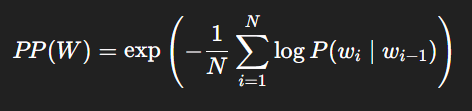

In [ ]:
def perplexity(sentence):

    words = sentence.lower().split()

    N = len(words)

    log_prob = sentence_log_probability(sentence)

    return math.exp(-log_prob / N)

In [ ]:
sentences = [
    "the king is dead",
    "the queen is beautiful",
    "computer runs software",
    "banana airplane quantum"
]

for s in sentences:

    pp = perplexity(s)

    print(f"{s}  ->  perplexity: {pp:.2f}")

the king is dead  ->  perplexity: 42.11
the queen is beautiful  ->  perplexity: 320.48
computer runs software  ->  perplexity: 10000.00
banana airplane quantum  ->  perplexity: 10000.00


# Generate Text Using Bigram

Sinh văn bản mới bằng cách lấy mẫu từ Bigram probability distribution đã học.

In [ ]:
def generate_bigram(start_word, length=20):

    word = start_word
    sentence = [word]

    for _ in range(length):

        if word not in bigram_counts:
            break

        next_words = list(bigram_counts[word].keys())
        weights = list(bigram_counts[word].values())

        word = random.choices(next_words, weights)[0]

        sentence.append(word)

    return " ".join(sentence)

In [ ]:
generate_bigram("king")

'king and very a jack. queen elizabeth: all points; and now even so he is my tale against our power, but'